In [19]:
# Filtern der 10 Datensätze, die 3 fach getestet wurden
# Unterschied in Bewertung für gleiche Frage feststellen (Mittelwert und dann Delta)
# 1. bei Originaltext
# 2. bei Transkript mit unterschiedlichen Sprechern

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Datensätze einlesen
df_stt = pd.read_csv("llm_evaluation_combined_stt.csv")
df_normal = pd.read_csv("llm_evaluation_combined_normal.csv")

#Zeile mit fehlendem Wert (Zeile 847) löschen
df_normal=df_normal.dropna(subset=["id"])

#Komma durch Punkt ersetzen in llm_rating
df_normal["llm_rating"] = df_normal["llm_rating"].str.replace(",",".",regex=False)
df_stt["human_score"] = df_stt["human_score"].astype(str).str.split("/").str[0]
df_stt["llm_rating"] = df_stt["llm_rating"].astype(str).str.split("/").str[0]
df_stt["llm_rating"] = df_stt["llm_rating"].str.replace(",",".",regex=False)

# ID in df_normal zu integer konvertieren
df_normal["id"] = df_normal["id"].astype(int)
df_normal["id"] = df_normal["id"].astype("category")

# llm_rating in df_normal zu float konvertieren
df_normal["llm_rating"] = df_normal["llm_rating"].astype(float)

df_normal.head()
df_stt.head()

#filtern der Datensätz, die jeweils von allen 3 Gruppenmitgliedern gleich gesprochen worden sind
id_list=[3,5,14,22,28,35,39,42,47,49] 

df_normal_filtered = df_normal[df_normal["id"].isin(id_list)].copy()
df_normal_filtered["id"].nunique()
#df_normal_filtered.head(50)

# Spalte "llm_rating_delta" einfügen



df_normal_filtered.to_csv("repro.csv")

In [54]:
# Gruppieren nach Modell und Bewertung
rating_variation = (df_normal_filtered.groupby(["model","id"])["llm_rating"].nunique().reset_index(name="n_unique_rating"))
#grouped = (df_normal_filtered.groupby(["model","llm_rating"]).size().reset_index(name="count"))

rating_variation["consistent"] = rating_variation["n_unique_rating"]==1
#grouped.head(20)

rating_variation = rating_variation[rating_variation["id"].isin(id_list)].copy()

model_consistency = (rating_variation.groupby("model")["consistent"].mean().reset_index(name="consistency_score"))
model_consistency["consistency_score"]*=100

/tmp/ipykernel_77821/3651973665.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_variation = (df_normal_filtered.groupby(["model","id"])["llm_rating"].nunique().reset_index(name="n_unique_rating"))


In [55]:
rating_variation.head(50)

,model,id,n_unique_rating,consistent
0,command-r7b:latest,3,3,False
1,command-r7b:latest,5,2,False
2,command-r7b:latest,14,1,True
3,command-r7b:latest,22,3,False
4,command-r7b:latest,28,3,False
5,command-r7b:latest,35,2,False
6,command-r7b:latest,39,1,True
7,command-r7b:latest,42,2,False
8,command-r7b:latest,47,2,False
9,command-r7b:latest,49,3,False


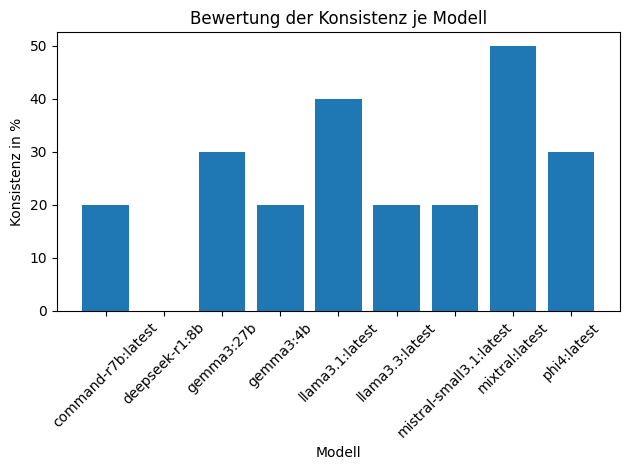

In [57]:
# Darstellen als Grafik
plt.figure()
plt.bar(model_consistency["model"], model_consistency["consistency_score"])

plt.xlabel("Modell")
plt.ylabel("Konsistenz in %")
plt.title("Bewertung der Konsistenz je Modell")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
